STEP 0 : STUDENT COURSE ENROLLMENT DATASET
   Attendance StudyHours PreviousGrade Interest  Assignment EnrollCourse
0        High       High          Good     High    Complete          Yes
1        High     Medium          Good     High    Complete          Yes
2        High       High          Good   Medium    Complete          Yes
3      Medium       High          Good     High    Complete          Yes
4      Medium       High       Average     High    Complete          Yes
5        High     Medium       Average     High    Complete          Yes
6      Medium     Medium       Average     High    Complete          Yes
7         Low        Low          Poor      Low  Incomplete           No
8         Low     Medium       Average      Low  Incomplete           No
9      Medium        Low          Poor      Low    Complete           No
10        Low        Low       Average   Medium  Incomplete           No
11     Medium        Low       Average      Low  Incomplete           No

Total e

/tmp/ipykernel_5371/2474496592.py:557: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


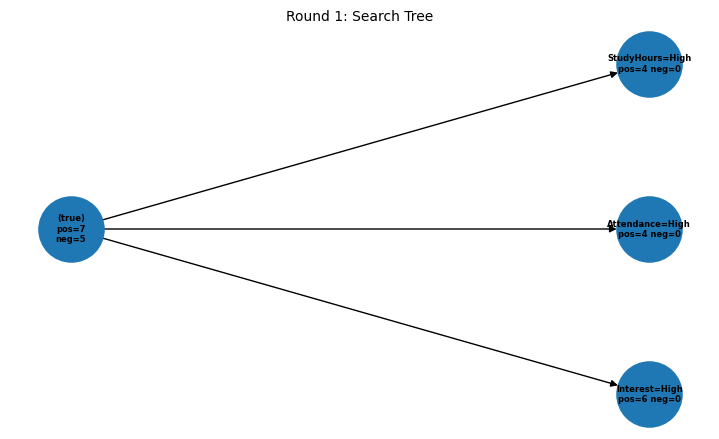

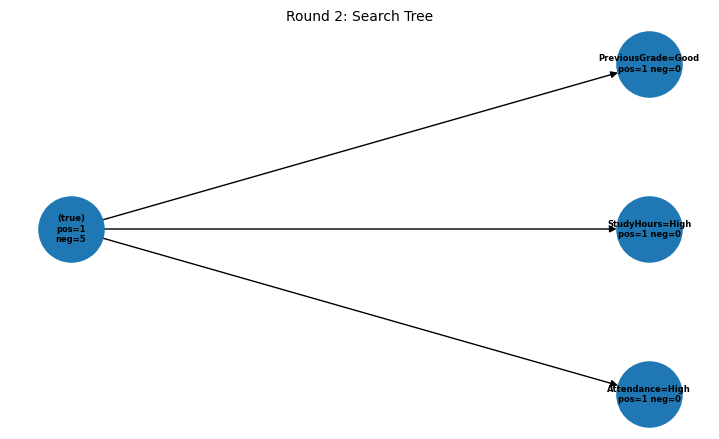

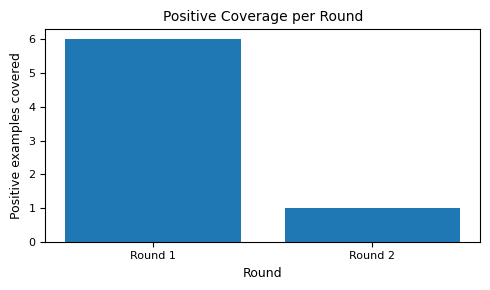

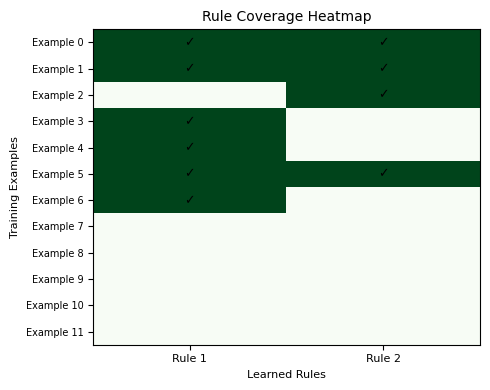

In [6]:

"""
Sequential Covering Algorithm — Small Graph Version
=====================================================
Module 2: Learning Sets of Rules

Dataset:
    Student Course Enrollment

The program:
  1. Displays the new dataset
  2. Runs LEARN-ONE-RULE using BEAM SEARCH
  3. Runs SEQUENTIAL-COVERING
  4. Generates small-size graphs:
       - Search tree
       - Positive coverage bar chart
       - Final rule coverage heatmap
"""

!pip install networkx -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx


# ------------------------------------------------------------------
# 1. NEW DATASET — STUDENT COURSE ENROLLMENT
# ------------------------------------------------------------------

columns = [
    "Attendance",
    "StudyHours",
    "PreviousGrade",
    "Interest",
    "Assignment",
    "EnrollCourse"
]

data = [

    # -------- POSITIVE EXAMPLES --------
    ["High",   "High",   "Good", "High",   "Complete", "Yes"],
    ["High",   "Medium", "Good", "High",   "Complete", "Yes"],
    ["High",   "High",   "Good", "Medium", "Complete", "Yes"],
    ["Medium", "High",   "Good", "High",   "Complete", "Yes"],

    # -------- POSITIVE EXAMPLES FOR SECOND RULE --------
    ["Medium", "High",   "Average", "High",   "Complete", "Yes"],
    ["High",   "Medium", "Average", "High",   "Complete", "Yes"],
    ["Medium", "Medium", "Average", "High",   "Complete", "Yes"],

    # -------- NEGATIVE EXAMPLES --------
    ["Low",    "Low",    "Poor",    "Low",    "Incomplete", "No"],
    ["Low",    "Medium", "Average", "Low",    "Incomplete", "No"],
    ["Medium", "Low",    "Poor",    "Low",    "Complete",   "No"],
    ["Low",    "Low",    "Average", "Medium", "Incomplete", "No"],
    ["Medium", "Low",    "Average", "Low",    "Incomplete", "No"],

]

df = pd.DataFrame(data, columns=columns)

TARGET_ATTR = "EnrollCourse"
TARGET_VAL = "Yes"

ATTRIBUTES = [
    c for c in columns
    if c != TARGET_ATTR
]

# Domain of every attribute
DOMAIN = {
    attr: sorted(df[attr].unique())
    for attr in ATTRIBUTES
}


# ------------------------------------------------------------------
# 2. PRINT DATASET
# ------------------------------------------------------------------

def print_dataset():

    print("=" * 70)
    print("STEP 0 : STUDENT COURSE ENROLLMENT DATASET")
    print("=" * 70)

    print(df.to_string(index=True))

    n_pos = (
        df[TARGET_ATTR] == TARGET_VAL
    ).sum()

    n_neg = (
        df[TARGET_ATTR] != TARGET_VAL
    ).sum()

    print(
        f"\nTotal examples: {len(df)}"
        f" | Positive (Yes): {n_pos}"
        f" | Negative (No): {n_neg}"
    )

    print()


# ------------------------------------------------------------------
# 3. RULE REPRESENTATION
# ------------------------------------------------------------------

def covers(rule, row):
    """Check whether a row satisfies a rule."""

    return all(
        row[attr] == val
        for attr, val in rule.items()
    )


def evaluate(rule, examples):
    """
    Returns:
        positives covered
        negatives covered
        precision
    """

    covered = examples[
        examples.apply(
            lambda r: covers(rule, r),
            axis=1
        )
    ]

    pos = (
        covered[TARGET_ATTR] == TARGET_VAL
    ).sum()

    neg = (
        covered[TARGET_ATTR] != TARGET_VAL
    ).sum()

    precision = (
        pos / (pos + neg)
        if (pos + neg) > 0
        else 0.0
    )

    return pos, neg, precision


def rule_to_str(rule):

    if not rule:
        return "IF (true)"

    conditions = " AND ".join(
        f"{a}={v}"
        for a, v in rule.items()
    )

    return f"IF {conditions}"


# ------------------------------------------------------------------
# 4. LEARN-ONE-RULE
# ------------------------------------------------------------------

def learn_one_rule(
    examples,
    beam_width=3,
    max_conditions=None
):

    if max_conditions is None:
        max_conditions = len(ATTRIBUTES)

    search_history = []

    # Start with most general rule
    beam = [{}]

    pos, neg, prec = evaluate(
        {},
        examples
    )

    search_history.append({
        "depth": 0,
        "candidates": [
            ({}, pos, neg, prec, None)
        ],
        "beam": [{}]
    })

    best_rule = {}
    best_pos = pos
    best_neg = neg
    best_prec = prec

    for depth in range(
        1,
        max_conditions + 1
    ):

        candidates = []

        for parent in beam:

            used_attrs = set(
                parent.keys()
            )

            for attr in ATTRIBUTES:

                if attr in used_attrs:
                    continue

                for val in DOMAIN[attr]:

                    child = dict(parent)
                    child[attr] = val

                    pos, neg, prec = evaluate(
                        child,
                        examples
                    )

                    # Ignore rules covering no positives
                    if pos == 0:
                        continue

                    candidates.append(
                        (
                            child,
                            pos,
                            neg,
                            prec,
                            parent
                        )
                    )

        if not candidates:
            break

        # Rank:
        # 1. Pure rules
        # 2. Precision
        # 3. Positive coverage

        candidates.sort(
            key=lambda c:
            (c[2] == 0, c[3], c[1]),
            reverse=True
        )

        # Keep only top candidates
        new_beam = []
        seen = set()

        for (
            child,
            pos,
            neg,
            prec,
            parent
        ) in candidates:

            key = frozenset(
                child.items()
            )

            if key not in seen:

                seen.add(key)
                new_beam.append(child)

            if len(new_beam) >= beam_width:
                break

        beam = new_beam

        search_history.append({
            "depth": depth,
            "candidates": candidates,
            "beam": beam
        })

        # Stop if a pure rule is found
        pure_candidates = [
            c for c in candidates
            if c[2] == 0
        ]

        if pure_candidates:

            top = pure_candidates[0]

            best_rule = top[0]
            best_pos = top[1]
            best_neg = top[2]
            best_prec = top[3]

            break

    return (
        best_rule,
        best_pos,
        best_neg,
        best_prec,
        search_history
    )


# ------------------------------------------------------------------
# 5. SEQUENTIAL COVERING
# ------------------------------------------------------------------

def sequential_covering(
    beam_width=3
):

    working = df.copy()

    rules = []
    round_logs = []

    round_num = 1

    while (
        working[TARGET_ATTR] == TARGET_VAL
    ).sum() > 0:

        (
            rule,
            pos,
            neg,
            prec,
            history
        ) = learn_one_rule(
            working,
            beam_width=beam_width
        )

        covered_mask = working.apply(
            lambda r: covers(rule, r),
            axis=1
        )

        covered_examples = (
            working[covered_mask]
        )

        covered_positive_idx = (
            covered_examples[
                covered_examples[TARGET_ATTR]
                == TARGET_VAL
            ].index.tolist()
        )

        print(
            f"--- Round {round_num} ---"
        )

        print(
            "Remaining positives before round :",
            (
                working[TARGET_ATTR]
                == TARGET_VAL
            ).sum()
        )

        print(
            "Learned rule :",
            rule_to_str(rule),
            "THEN",
            TARGET_ATTR,
            "=",
            TARGET_VAL
        )

        print(
            "Covers :",
            pos,
            "positive(s),",
            neg,
            "negative(s)"
        )

        print(
            "Positive indices covered :",
            covered_positive_idx
        )

        print()

        rules.append(rule)

        round_logs.append({
            "round": round_num,
            "rule": rule,
            "pos_covered": pos,
            "neg_covered": neg,
            "covered_positive_idx":
                covered_positive_idx,
            "history": history
        })

        # Remove covered positive examples
        working = working.drop(
            index=covered_positive_idx
        )

        round_num += 1

        # Safety condition
        if pos == 0:
            break

    return rules, round_logs


# ------------------------------------------------------------------
# 6. SMALL SEARCH TREE GRAPH
# ------------------------------------------------------------------

def plot_search_tree(
    history,
    winning_rule,
    round_num
):

    G = nx.DiGraph()

    labels = {}
    node_id_of_rule = {}

    def node_id(rule):

        key = frozenset(
            rule.items()
        )

        if key not in node_id_of_rule:

            node_id_of_rule[key] = (
                f"n{len(node_id_of_rule)}"
            )

        return node_id_of_rule[key]

    # Root
    root_pos = history[0]["candidates"][0][1]
    root_neg = history[0]["candidates"][0][2]

    root_id = node_id({})

    G.add_node(root_id)

    labels[root_id] = (
        f"(true)\npos={root_pos}\n"
        f"neg={root_neg}"
    )

    winning_key = frozenset(
        winning_rule.items()
    )

    # Candidates kept in beam
    kept_keys = set()

    for level in history:

        for rule in level["beam"]:

            kept_keys.add(
                frozenset(rule.items())
            )

    kept_keys.add(winning_key)

    # Add nodes
    for level in history[1:]:

        for (
            child,
            pos,
            neg,
            prec,
            parent
        ) in level["candidates"]:

            key = frozenset(
                child.items()
            )

            if key not in kept_keys:
                continue

            cid = node_id(child)
            pid = node_id(parent)

            if not G.has_node(cid):

                G.add_node(cid)

                label = " AND ".join(
                    f"{a}={v}"
                    for a, v in child.items()
                )

                labels[cid] = (
                    f"{label}\n"
                    f"pos={pos} neg={neg}"
                )

            G.add_edge(pid, cid)

    # Layout
    for layer, nodes in enumerate(
        nx.bfs_layers(
            G,
            root_id
        )
    ):

        for n in nodes:
            G.nodes[n]["layer"] = layer

    pos_layout = nx.multipartite_layout(
        G,
        subset_key="layer"
    )

    # Small graph size
    plt.figure(
        figsize=(7, 4)
    )

    nx.draw(
        G,
        pos_layout,
        labels=labels,
        with_labels=True,
        node_size=2200,
        font_size=6,
        font_weight="bold",
        arrows=True
    )

    plt.title(
        f"Round {round_num}: Search Tree",
        fontsize=10
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 7. SMALL POSITIVE COVERAGE BAR GRAPH
# ------------------------------------------------------------------

def plot_coverage_bar(
    round_logs
):

    rounds = [
        f"Round {rl['round']}"
        for rl in round_logs
    ]

    covered = [
        rl["pos_covered"]
        for rl in round_logs
    ]

    # Small graph size
    plt.figure(
        figsize=(5, 3)
    )

    plt.bar(
        rounds,
        covered
    )

    plt.xlabel(
        "Round",
        fontsize=9
    )

    plt.ylabel(
        "Positive examples covered",
        fontsize=9
    )

    plt.title(
        "Positive Coverage per Round",
        fontsize=10
    )

    plt.xticks(
        fontsize=8
    )

    plt.yticks(
        fontsize=8
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 8. SMALL FINAL COVERAGE HEATMAP
# ------------------------------------------------------------------

def plot_coverage_heatmap(
    rules
):

    n = len(df)
    m = len(rules)

    matrix = [
        [
            1 if covers(
                rule,
                df.loc[i]
            )
            else 0
            for rule in rules
        ]
        for i in range(n)
    ]

    # Small graph size
    plt.figure(
        figsize=(5, 4)
    )

    plt.imshow(
        matrix,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=1
    )

    plt.xticks(
        range(m),
        [
            f"Rule {i+1}"
            for i in range(m)
        ],
        fontsize=8
    )

    plt.yticks(
        range(n),
        [
            f"Example {i}"
            for i in range(n)
        ],
        fontsize=7
    )

    # Add check marks
    for i in range(n):

        for j in range(m):

            if matrix[i][j]:

                plt.text(
                    j,
                    i,
                    "✓",
                    ha="center",
                    va="center",
                    fontsize=9
                )

    plt.title(
        "Rule Coverage Heatmap",
        fontsize=10
    )

    plt.xlabel(
        "Learned Rules",
        fontsize=8
    )

    plt.ylabel(
        "Training Examples",
        fontsize=8
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------------
# 9. MAIN PROGRAM
# ------------------------------------------------------------------

print_dataset()


print("=" * 70)
print("STEP 1 : RUNNING SEQUENTIAL COVERING")
print("=" * 70)


rules, round_logs = (
    sequential_covering(
        beam_width=3
    )
)


print("=" * 70)
print("FINAL LEARNED RULE SET")
print("=" * 70)


for i, rule in enumerate(
    rules,
    start=1
):

    print(
        f"Rule {i}: "
        f"{rule_to_str(rule)} "
        f"THEN {TARGET_ATTR} = {TARGET_VAL}"
    )


print()


# ------------------------------------------------------------------
# 10. GENERATE SMALL GRAPHS
# ------------------------------------------------------------------

print("=" * 70)
print("STEP 2 : GENERATING SMALL GRAPHS")
print("=" * 70)


# Search tree
for rl in round_logs:

    plot_search_tree(
        rl["history"],
        rl["rule"],
        rl["round"]
    )

# Coverage bar chart
plot_coverage_bar(
    round_logs
)


# Coverage heatmap
plot_coverage_heatmap(
    rules
)
